## 00. Scratchpad 

### 1. Uploading .tsv file

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import clear_output

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import pandas as pd
import os
import re
import time

from collections import Counter
from collections import defaultdict

from statistics import mean
import math

In [2]:
os.listdir("../data/tatoeba_1")

['eng-pol_1.tsv']

In [3]:
df = pd.read_csv('../data/tatoeba_1/eng-pol_1.tsv', sep='\t', header=None).drop([0, 2], axis=1)
df.columns = ['eng_text', 'pol_text']
df.head()

,eng_text,pol_text
0,Let's try something.,Spróbujmy coś.
1,I have to go to sleep.,Muszę iść spać.
2,Muiriel is 20 now.,Muiriel ma teraz 20 lat.
3,"The password is ""Muiriel"".",Hasło brzmi „Muiriel”.
4,"The password is ""Muiriel"".",Hasło to „Muiriel”.


In [4]:
df = pd.read_csv('../data/tatoeba_1/eng-pol_1.tsv', sep='\t', header=None)
df = df.drop([0, 2], axis=1)
df.head()

,1,3
0,Let's try something.,Spróbujmy coś.
1,I have to go to sleep.,Muszę iść spać.
2,Muiriel is 20 now.,Muiriel ma teraz 20 lat.
3,"The password is ""Muiriel"".",Hasło brzmi „Muiriel”.
4,"The password is ""Muiriel"".",Hasło to „Muiriel”.


In [5]:
df = pd.read_csv('../data/tatoeba_1/eng-pol_1.tsv', sep='\t', header=None)
df.columns = ['eng_id', 'eng_text', 'pol_id', 'pol_text']
df = df.drop(['eng_id', 'pol_id'], axis=1)
print("Shape:", df.shape)
df.head()

Shape: (83891, 2)


,eng_text,pol_text
0,Let's try something.,Spróbujmy coś.
1,I have to go to sleep.,Muszę iść spać.
2,Muiriel is 20 now.,Muiriel ma teraz 20 lat.
3,"The password is ""Muiriel"".",Hasło brzmi „Muiriel”.
4,"The password is ""Muiriel"".",Hasło to „Muiriel”.


In [6]:
class DataframeModule():
    def __init__(self, path, sep='\t', is_header=None):
        self.df = pd.read_csv(path, sep=sep, header=is_header)
        self.len_df = len(self.df)
        print("Df shape:", self.df.shape)

    def df_head(self, num):
        return self.df.head(num)
        
    def drop_cols(self, col_names):
        self.df = self.df.drop(col_names, axis=1)

    def rename_cols(self, col_names):
        self.df.columns = col_names

    def info_describe(self):
        print(f"{'='*80}\n{'DATAFRAME DESCRIBE':^80}\n{'-'*80}")
        print(f"{self.df.describe().T}\n{'='*80}\n{'DATAFRAME INFO':^80}\n{'-'*80}")
        print(f"{self.df.info()}\n{'='*80}")

    def vanity_check(self, names_tup):
        src_col, lbl_col = names_tup
        
        nan_src = self.df[src_col].isna().sum()
        nan_lbl = self.df[lbl_col].isna().sum()
        print(f"NaN VALUES COUNT\n{src_col}: {nan_src} | {lbl_col}: {nan_lbl}\n")
        
        print(f"{src_col}: {nan_src} | {lbl_col}: {nan_lbl}\n{'='*56}\n{'DUPLICATED VALUES COUNT':^56}\n{'-'*56}")
        
        dup_src = self.df[src_col].duplicated().sum()
        dup_lbl = self.df[lbl_col].duplicated().sum()
        dup_both = self.df[[src_col, lbl_col]].duplicated().sum()
        print(f"DUPLICATED VALUES COUNT\n{src_col}: {dup_src} | {lbl_col}: {dup_lbl} | ")
        print(f"{src_col}: {dup_src} | {lbl_col}: {dup_lbl} | [{lbl_col}|{src_col}]: {dup_both}\n{'='*56}")

### 2.  EDA

In [7]:
df.describe().T

,count,unique,top,freq
eng_text,83891,75426,Years have passed before I fully understood my...,16
pol_text,83891,78321,Nie musisz do mnie dzwonić.,11


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83891 entries, 0 to 83890
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   eng_text  83891 non-null  object
 1   pol_text  83891 non-null  object
dtypes: object(2)
memory usage: 1.3+ MB


In [9]:
df.isna().sum(), " ", df.duplicated().sum()

(eng_text    0
 pol_text    0
 dtype: int64,
 ' ',
 0)

In [10]:
print("eng_text:", df['eng_text'].unique().__len__(), "|", "pol_text:", df['pol_text'].unique().__len__())
print("eng_text:", df['eng_text'].duplicated().sum(), " |", "pol_text:", df['pol_text'].duplicated().sum())
print(f"[eng_text | pol_text]: {df[['eng_text', 'pol_text']].duplicated().sum()} ")

eng_text: 75426 | pol_text: 78321
eng_text: 8465  | pol_text: 5570
[eng_text | pol_text]: 0 


In [11]:
df['eng_text'].str.split().str.len().describe(), "", df['pol_text'].str.split().str.len().describe()

(count    83891.000000
 mean         6.173296
 std          3.179354
 min          1.000000
 25%          4.000000
 50%          6.000000
 75%          8.000000
 max         94.000000
 Name: eng_text, dtype: float64,
 '',
 count    83891.000000
 mean         5.046262
 std          2.679377
 min          1.000000
 25%          3.000000
 50%          5.000000
 75%          6.000000
 max         90.000000
 Name: pol_text, dtype: float64)

In [12]:
df['len_eng'] = df['eng_text'].str.split().str.len()
df['len_pol'] = df['pol_text'].str.split().str.len()
df.head()

,eng_text,pol_text,len_eng,len_pol
0,Let's try something.,Spróbujmy coś.,3,2
1,I have to go to sleep.,Muszę iść spać.,6,3
2,Muiriel is 20 now.,Muiriel ma teraz 20 lat.,4,5
3,"The password is ""Muiriel"".",Hasło brzmi „Muiriel”.,4,3
4,"The password is ""Muiriel"".",Hasło to „Muiriel”.,4,3


In [13]:
df.nlargest(10, 'len_eng')

,eng_text,pol_text,len_eng,len_pol
52978,You say that you're afraid of being disliked b...,"Mówisz, że boisz się bycia nielubianym przez i...",94,90
67060,My apartment has a very convenient bathroom. Y...,Moje mieszkanie ma bardzo wygodną łazienkę. Wc...,82,66
79934,You say you're afraid of being disliked by oth...,"Mówisz, że boisz się bycia nielubianym przez i...",77,90
77841,"I know what you want, said the sea witch. ""It ...","Wiem, czego pragniesz, rzekła morska wiedźma. ...",71,54
12655,Consider what we do to our children. We do not...,"Popatrz, co robimy naszym dzieciom. Nie mówimy...",70,56
31040,"For the past few years, teenagers who imitate ...",W ostatnich latach nastolatkowie udający otyły...,70,63
66971,"One day, I woke up to find that God had put ha...","Pewnego dnia obudziłem się i spostrzegłem, że ...",70,52
11946,"A little bit earlier this evening, I received ...",Niedawno zechciał zadzwonić do mnie pan senato...,65,47
11947,"America, we have come so far. We have seen so ...","Ameryko, dotarliśmy tak daleko. Widzieliśmy ta...",61,51
11948,"America, we have come so far. We have seen so ...","Daleko zaszliśmy, Ameryko. Wiele widzieliśmy, ...",61,43


In [14]:
df.nlargest(10, 'len_pol')

,eng_text,pol_text,len_eng,len_pol
52978,You say that you're afraid of being disliked b...,"Mówisz, że boisz się bycia nielubianym przez i...",94,90
79934,You say you're afraid of being disliked by oth...,"Mówisz, że boisz się bycia nielubianym przez i...",77,90
67060,My apartment has a very convenient bathroom. Y...,Moje mieszkanie ma bardzo wygodną łazienkę. Wc...,82,66
31040,"For the past few years, teenagers who imitate ...",W ostatnich latach nastolatkowie udający otyły...,70,63
12655,Consider what we do to our children. We do not...,"Popatrz, co robimy naszym dzieciom. Nie mówimy...",70,56
77841,"I know what you want, said the sea witch. ""It ...","Wiem, czego pragniesz, rzekła morska wiedźma. ...",71,54
34069,One of the reasons Twitter is popular in Japan...,Jedną z przyczyn popularności Twittera w Japon...,57,53
66971,"One day, I woke up to find that God had put ha...","Pewnego dnia obudziłem się i spostrzegłem, że ...",70,52
11947,"America, we have come so far. We have seen so ...","Ameryko, dotarliśmy tak daleko. Widzieliśmy ta...",61,51
11946,"A little bit earlier this evening, I received ...",Niedawno zechciał zadzwonić do mnie pan senato...,65,47


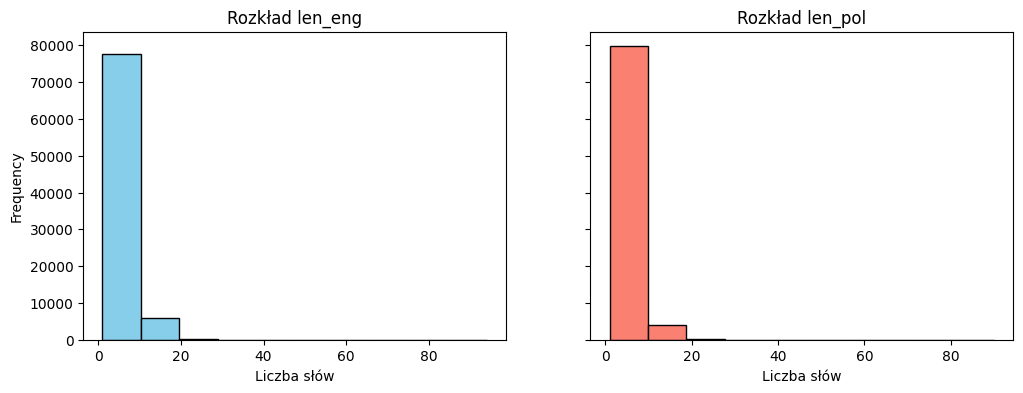

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

df["len_eng"].plot(kind="hist", ax=ax1, color="skyblue", edgecolor="black")
ax1.set_title("Rozkład len_eng")
ax1.set_xlabel("Liczba słów")


df["len_pol"].plot(kind="hist", ax=ax2, color="salmon", edgecolor="black")
ax2.set_title("Rozkład len_pol")
ax2.set_xlabel("Liczba słów")

plt.show()

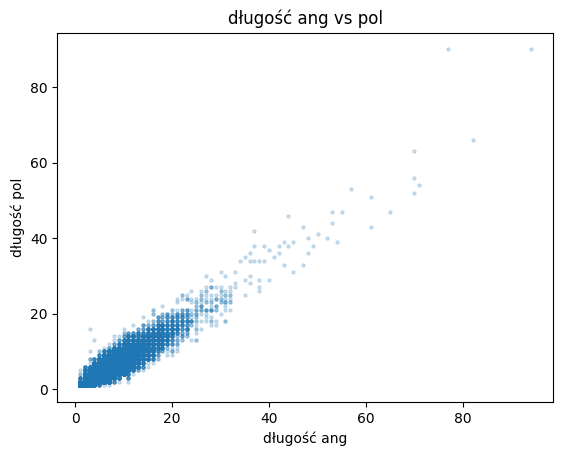

In [16]:
plt.scatter(df['len_eng'], df['len_pol'], alpha=0.2, s=5)
plt.xlabel('długość ang')
plt.ylabel('długość pol')
plt.title('długość ang vs pol')
plt.show()

In [17]:
# df = df[(df['len_eng'] <= 20) & (df['len_pol'] <= 20)]
# len(df)

In [18]:
# plt.scatter(df['len_eng'], df['len_pol'], alpha=0.2, s=5)
# plt.xlabel('długość ang')
# plt.ylabel('długość pol')
# plt.title('długość ang vs pol')
# plt.show()

In [19]:
df.head(), df.shape

(                     eng_text                  pol_text  len_eng  len_pol
 0        Let's try something.            Spróbujmy coś.        3        2
 1      I have to go to sleep.           Muszę iść spać.        6        3
 2          Muiriel is 20 now.  Muiriel ma teraz 20 lat.        4        5
 3  The password is "Muiriel".    Hasło brzmi „Muiriel”.        4        3
 4  The password is "Muiriel".       Hasło to „Muiriel”.        4        3,
 (83891, 4))

### 3. Tokenization

In [20]:
def tokenize_data(df, src_col, tgt_col):
    df_proc = df.copy()
    df_proc[src_col] = df_proc[src_col].apply(
        tokenize_snt, 
        regex_del = r"""['"€;:()$%–—‘’°“”₳+&#=‐…−/£@-]""",
        tok_func = lambda x: x + ['<eos>'])
                                             
    df_proc[tgt_col] = df_proc[tgt_col].apply(
        tokenize_snt, 
        regex_del = r"""[]„”€…";:()'%/’$\u200b\xad–°+₳#'\[=−­`—“@«»-]""",
        tok_func = lambda x: ['<bos>'] + x + ['<eos>'])
    return df_proc

In [21]:
def tokenize_snt(snt, regex_del, tok_func):        
    snt = re.sub(regex_del, '', snt.lower())
    snt = re.sub(r'\s*([.,!?])\s*', r' \1 ', snt)
    return tok_func(re.split(r'\s+', snt.strip()))

In [22]:
def tokenize_eng(sentence):
    sentence = re.sub(r"""['"€;:()$%–—‘’°“”₳+&#=‐…−/£@-]""", '', sentence.lower())
    sentence = re.sub(r'\s*([.,!?])\s*', r' \1 ', sentence.lower())
    return re.split(r'\s+', sentence.strip()) + ['<eos>']

In [23]:
def tokenize_pol(sentence):
    #clean_pattern = r"""[]„”€…";:()'%/’$\u200b\xad–°+₳#'\[=−­`—“@«»-]"""
    sentence = re.sub(r"""[]„”€…";:()'%/’$\u200b\xad–°+₳#'\[=−­`—“@«»-]""", '', sentence.lower())
    sentence = re.sub(r'\s*([.,!?])\s*', r' \1 ', sentence.lower())
    return ['<bos>'] + re.split(r'\s+', sentence.strip()) + ['<eos>']

In [24]:
def test_after(col):
    all_text = "".join(col.apply(lambda x: ''.join(x)).astype(str))
    non_letters = re.findall(r'[^\w\s]', all_text)
    occurrences = Counter(non_letters)
    return list(occurrences.keys())

In [25]:
df = df.drop(['len_eng', 'len_pol'], axis=1)

In [26]:
df.head()

,eng_text,pol_text
0,Let's try something.,Spróbujmy coś.
1,I have to go to sleep.,Muszę iść spać.
2,Muiriel is 20 now.,Muiriel ma teraz 20 lat.
3,"The password is ""Muiriel"".",Hasło brzmi „Muiriel”.
4,"The password is ""Muiriel"".",Hasło to „Muiriel”.


In [27]:
import Data

In [28]:
df_proc = Data.tokenize_data(df, 'eng_text', 'pol_text')

In [29]:
df_proc.head()

,eng_text,pol_text,eng_len,pol_len
0,"[lets, try, something, ., <eos>]","[<bos>, spróbujmy, coś, ., <eos>]",5,5
1,"[i, have, to, go, to, sleep, ., <eos>]","[<bos>, muszę, iść, spać, ., <eos>]",8,6
2,"[muiriel, is, 20, now, ., <eos>]","[<bos>, muiriel, ma, teraz, 20, lat, ., <eos>]",6,8
3,"[the, password, is, muiriel, ., <eos>]","[<bos>, hasło, brzmi, muiriel, ., <eos>]",6,6
4,"[the, password, is, muiriel, ., <eos>]","[<bos>, hasło, to, muiriel, ., <eos>]",6,6


In [30]:
df_proc['eng_len'].describe(), " ", df_proc['pol_len'].describe()

(count    83891.000000
 mean         8.276061
 std          3.374852
 min          3.000000
 25%          6.000000
 50%          8.000000
 75%         10.000000
 max        104.000000
 Name: eng_len, dtype: float64,
 ' ',
 count    83891.000000
 mean         8.291068
 std          3.055119
 min          3.000000
 25%          6.000000
 50%          8.000000
 75%          9.000000
 max        108.000000
 Name: pol_len, dtype: float64)

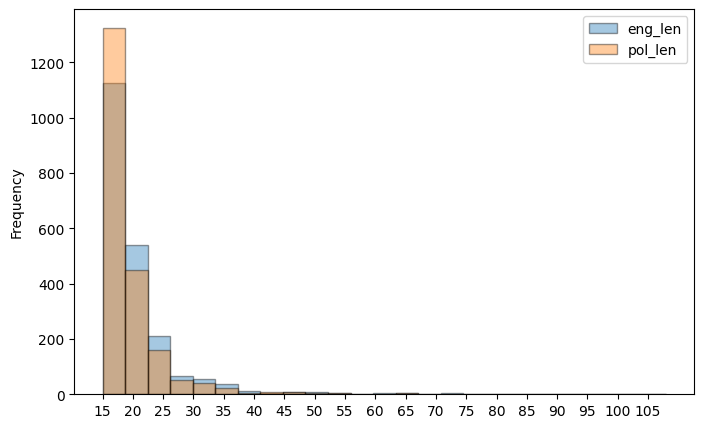

In [31]:
limit = 15
df_filtrowany = df_proc[(df_proc["eng_len"] >= limit) & (df_proc["pol_len"] >= limit)]

df_filtrowany[["eng_len", "pol_len"]].plot(
    kind="hist", alpha=0.4, bins=25, edgecolor="black", figsize=(8, 5)
)

v_max = int(df_filtrowany[["eng_len", "pol_len"]].max().max())
plt.xticks(range(limit, v_max + 1, 5))

plt.show()

In [32]:
df_proc.nlargest(10, 'eng_len')

,eng_text,pol_text,eng_len,pol_len
52978,"[you, say, that, youre, afraid, of, being, dis...","[<bos>, mówisz, ,, że, boisz, się, bycia, niel...",104,108
67060,"[my, apartment, has, a, very, convenient, bath...","[<bos>, moje, mieszkanie, ma, bardzo, wygodną,...",94,81
79934,"[you, say, youre, afraid, of, being, disliked,...","[<bos>, mówisz, ,, że, boisz, się, bycia, niel...",87,108
12655,"[consider, what, we, do, to, our, children, .,...","[<bos>, popatrz, ,, co, robimy, naszym, dzieci...",82,73
66971,"[one, day, ,, i, woke, up, to, find, that, god...","[<bos>, pewnego, dnia, obudziłem, się, i, spos...",81,66
77841,"[i, know, what, you, want, ,, said, the, sea, ...","[<bos>, wiem, ,, czego, pragniesz, ,, rzekła, ...",81,69
31040,"[for, the, past, few, years, ,, teenagers, who...","[<bos>, w, ostatnich, latach, nastolatkowie, u...",78,72
11946,"[a, little, bit, earlier, this, evening, ,, i,...","[<bos>, niedawno, zechciał, zadzwonić, do, mni...",72,54
11947,"[america, ,, we, have, come, so, far, ., we, h...","[<bos>, ameryko, ,, dotarliśmy, tak, daleko, ....",72,64
11948,"[america, ,, we, have, come, so, far, ., we, h...","[<bos>, daleko, zaszliśmy, ,, ameryko, ., wiel...",72,53


In [33]:
df_proc.nlargest(10, 'pol_len')

,eng_text,pol_text,eng_len,pol_len
52978,"[you, say, that, youre, afraid, of, being, dis...","[<bos>, mówisz, ,, że, boisz, się, bycia, niel...",104,108
79934,"[you, say, youre, afraid, of, being, disliked,...","[<bos>, mówisz, ,, że, boisz, się, bycia, niel...",87,108
67060,"[my, apartment, has, a, very, convenient, bath...","[<bos>, moje, mieszkanie, ma, bardzo, wygodną,...",94,81
12655,"[consider, what, we, do, to, our, children, .,...","[<bos>, popatrz, ,, co, robimy, naszym, dzieci...",82,73
31040,"[for, the, past, few, years, ,, teenagers, who...","[<bos>, w, ostatnich, latach, nastolatkowie, u...",78,72
77841,"[i, know, what, you, want, ,, said, the, sea, ...","[<bos>, wiem, ,, czego, pragniesz, ,, rzekła, ...",81,69
66971,"[one, day, ,, i, woke, up, to, find, that, god...","[<bos>, pewnego, dnia, obudziłem, się, i, spos...",81,66
14996,"[the, esperanto, alphabet, consists, of, 28, l...","[<bos>, alfabet, esperanto, składa, się, z, 28...",64,65
11947,"[america, ,, we, have, come, so, far, ., we, h...","[<bos>, ameryko, ,, dotarliśmy, tak, daleko, ....",72,64
34069,"[one, of, the, reasons, twitter, is, popular, ...","[<bos>, jedną, z, przyczyn, popularności, twit...",63,62


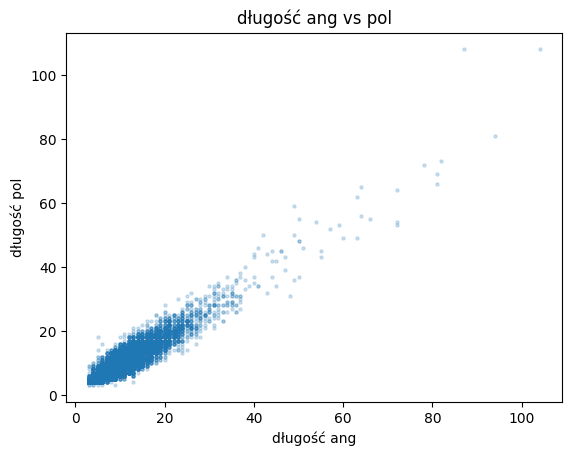

In [34]:
plt.scatter(df_proc['eng_len'], df_proc['pol_len'], alpha=0.2, s=5)
plt.xlabel('długość ang')
plt.ylabel('długość pol')
plt.title('długość ang vs pol')
plt.show()

In [35]:
df_proc = Data.trim_data(df_proc, 'eng_len', 'pol_len', 30)

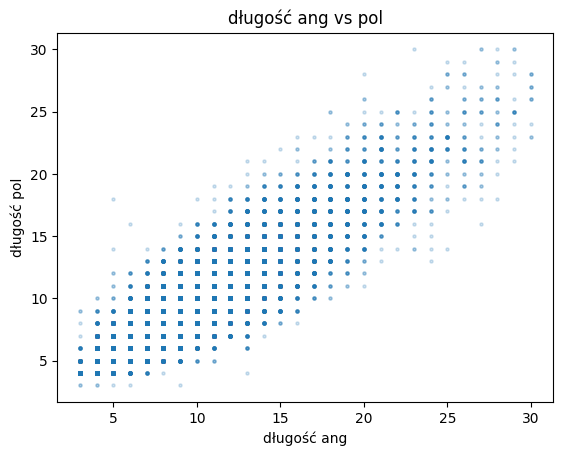

In [36]:
plt.scatter(df_proc['eng_len'], df_proc['pol_len'], alpha=0.2, s=5)
plt.xlabel('długość ang')
plt.ylabel('długość pol')
plt.title('długość ang vs pol')
plt.show()

In [175]:
def set_vocab(df, col, min_freq=2, is_tgt=False):
    leng_c = Counter(df[col].explode())
    leng_c = {k: v for k, v in leng_c.items() if v >= min_freq}
    
    toks_c = dict(sorted(leng_c.items(), key=lambda item: item[1], reverse=True))
    vocab = {'<pad>': 0, '<unk>': 1, '<eos>': 2}
    if is_tgt:
        vocab['<bos>'] = 3
        
    for tok in vocab:
        toks_c.pop(tok, None)

    for i, k in enumerate(toks_c.keys(), len(vocab)):
        vocab[k] = i
    return vocab

In [176]:
def tokens_to_id(df, src_col, tgt_col, min_freq=2):
    df_proc = df.copy()
    eng_vcb = set_vocab(df_proc, src_col, min_freq=min_freq)
    pol_vcb = set_vocab(df_proc, tgt_col, min_freq=min_freq, is_tgt=True)

    eng_unk, pol_unk = eng_vcb['<unk>'], pol_vcb['<unk>']
    df_proc['src_ids'] = df_proc[src_col].apply(lambda snt: [eng_vcb.get(tok, eng_unk) for tok in snt])
    df_proc['lbl_ids'] = df_proc[tgt_col].apply(lambda snt: [pol_vcb.get(tok, pol_unk) for tok in snt])
    return df_proc, eng_vcb, pol_vcb

In [177]:
test_proc, engvb, polvb = tokens_to_id(df_proc, 'eng_text', 'pol_text')

In [178]:
test_proc

,eng_text,pol_text,eng_len,pol_len,src_ids,lbl_ids
0,"[lets, try, something, ., <eos>]","[<bos>, spróbujmy, coś, ., <eos>]",5,5,"[157, 270, 122, 3, 2]","[3, 3400, 69, 4, 2]"
1,"[i, have, to, go, to, sleep, ., <eos>]","[<bos>, muszę, iść, spać, ., <eos>]",8,6,"[5, 20, 6, 54, 6, 327, 3, 2]","[3, 89, 103, 293, 4, 2]"
2,"[muiriel, is, 20, now, ., <eos>]","[<bos>, muiriel, ma, teraz, 20, lat, ., <eos>]",6,8,"[3438, 11, 1741, 94, 3, 2]","[3, 4363, 26, 75, 1341, 115, 4, 2]"
3,"[the, password, is, muiriel, ., <eos>]","[<bos>, hasło, brzmi, muiriel, ., <eos>]",6,6,"[4, 2041, 11, 3438, 3, 2]","[3, 3401, 899, 4363, 4, 2]"
4,"[the, password, is, muiriel, ., <eos>]","[<bos>, hasło, to, muiriel, ., <eos>]",6,6,"[4, 2041, 11, 3438, 3, 2]","[3, 3401, 11, 4363, 4, 2]"
...,...,...,...,...,...,...
83886,"[are, you, going, to, the, market, ?, <eos>]","[<bos>, idziesz, na, rynek, ?, <eos>]",8,6,"[24, 7, 71, 6, 4, 1804, 10, 2]","[3, 944, 13, 3466, 7, 2]"
83887,"[i, only, drink, beer, ., <eos>]","[<bos>, piję, tylko, piwo, ., <eos>]",6,6,"[5, 131, 229, 586, 3, 2]","[3, 1064, 60, 694, 4, 2]"
83888,"[the, water, isnt, very, cold, ., <eos>]","[<bos>, woda, nie, jest, bardzo, zimna, ., <eos>]",7,8,"[4, 206, 112, 63, 285, 3, 2]","[3, 550, 6, 10, 36, 1775, 4, 2]"
83889,"[is, black, tea, healthy, ?, <eos>]","[<bos>, czy, czarna, herbata, jest, zdrowa, ?,...",6,8,"[11, 513, 482, 885, 10, 2]","[3, 17, 4354, 2784, 10, 3795, 7, 2]"


In [181]:
eng_c = Counter((' '.join(df_proc['eng_text'].explode())).split())
pol_c = Counter((' '.join(df_proc['pol_text'].explode())).split())

In [182]:
len(test_1)

19102

In [183]:
dict(sorted(pol_c.items(), key=lambda item: item[1], reverse=True))

{'<bos>': 83752,
 '<eos>': 83752,
 '.': 71031,
 ',': 18808,
 'nie': 15608,
 '?': 11730,
 'się': 10189,
 'tom': 9856,
 'jest': 9592,
 'to': 8705,
 'w': 8345,
 'na': 6541,
 'że': 5820,
 'do': 4576,
 'z': 4402,
 'czy': 3196,
 'co': 2921,
 'i': 2598,
 'jak': 2500,
 'o': 2286,
 'mi': 2264,
 'mnie': 2230,
 '!': 2227,
 'mary': 2218,
 'ma': 1919,
 'on': 1898,
 'jestem': 1897,
 'po': 1824,
 'tego': 1771,
 'za': 1720,
 'są': 1484,
 'mam': 1433,
 'jesteś': 1425,
 'był': 1391,
 'bardzo': 1389,
 'tak': 1269,
 'toma': 1235,
 'ten': 1228,
 'ci': 1177,
 'od': 1147,
 'tym': 1133,
 'ona': 1089,
 'już': 1081,
 'mogę': 1007,
 'zrobić': 929,
 'go': 912,
 'cię': 902,
 'chcę': 897,
 'nigdy': 890,
 'mój': 883,
 'być': 876,
 'kiedy': 875,
 'dla': 862,
 'jego': 847,
 'może': 846,
 'ale': 827,
 'domu': 827,
 'gdzie': 813,
 'tylko': 811,
 'tu': 804,
 'żeby': 791,
 'jej': 790,
 'będzie': 785,
 'było': 751,
 'masz': 750,
 'wiem': 740,
 'powiedział': 726,
 'coś': 724,
 'dlaczego': 698,
 'kto': 677,
 'wszystko': 641,

In [184]:
min_freq = 2
eng_unk = sum(1 for k in eng_c.keys() if eng_c[k] < min_freq)
pol_unk = sum(1 for k in pol_c.keys() if pol_c[k] < min_freq)
print(f"Eng unknown count: {eng_unk} | {eng_unk/len(eng_c)*100:.3f}%")
print(f"Pol unknown count: {pol_unk} | {pol_unk/len(pol_c)*100:.3f}%")

Eng unknown count: 5886 | 38.466%
Pol unknown count: 19281 | 50.236%


In [185]:
def set_vocab(leng_c):
    len_toks = dict(sorted(leng_c.items(), key=lambda item: item[1], reverse=True))
    tok_to_id = {'<pad>': 0, '<unk>': 1}
    for i, k in enumerate(len_toks.keys(), 2):
        tok_to_id[k] = i
    return tok_to_id

In [186]:
eng_c2 = {k: v for k, v in eng_c.items() if v >= min_freq}
pol_c2 = {k: v for k, v in pol_c.items() if v >= min_freq}

print(len(eng_c) - len(eng_c2))
print(len(pol_c) - len(pol_c2))

5886
19281


In [187]:
eng_vocab = set_vocab(eng_c2)
eng_vocab_rev = {v: k for k, v in eng_vocab.items()}
pol_vocab = set_vocab(pol_c2)
pol_vocab_rev = {v: k for k, v in pol_vocab.items()}
print(list(eng_vocab.items())[:10])
print(list(pol_vocab.items())[:10])

[('<pad>', 0), ('<unk>', 1), ('<eos>', 2), ('.', 3), ('the', 4), ('i', 5), ('to', 6), ('you', 7), ('a', 8), ('tom', 9)]
[('<pad>', 0), ('<unk>', 1), ('<bos>', 2), ('<eos>', 3), ('.', 4), (',', 5), ('nie', 6), ('?', 7), ('się', 8), ('tom', 9)]


In [188]:
len(eng_vocab), len(pol_vocab)

(9418, 19102)

In [189]:
def tokens_to_id(sentence, leng_vocab):
    return [leng_vocab[tok] if tok in leng_vocab else leng_vocab['<unk>'] for tok in sentence]

In [190]:
df['eng_ids'] = df['eng_text'].apply(lambda x: tokens_to_id(x, eng_vocab))
df['pol_ids'] = df['pol_text'].apply(lambda x: tokens_to_id(x, pol_vocab))
df.head()

,eng_text,pol_text,eng_ids,pol_ids
0,Let's try something.,Spróbujmy coś.,"[1, 7349, 1, 1, 5337, 1, 1, 1, 1, 1, 5337, 423...","[1, 2244, 15271, 1, 6638, 401, 1, 1, 1, 1, 309..."
1,I have to go to sleep.,Muszę iść spać.,"[1, 1, 8010, 8, 8083, 7349, 1, 1, 4239, 1, 1, ...","[1, 401, 1, 16, 1, 1, 19, 1, 1, 1, 1, 2244, 10..."
2,Muiriel is 20 now.,Muiriel ma teraz 20 lat.,"[1, 5336, 5, 1, 5, 7349, 1, 1, 5, 5337, 1, 206...","[1, 401, 19, 15271, 19, 8233, 1, 1, 1, 106, 1,..."
3,"The password is ""Muiriel"".",Hasło brzmi „Muiriel”.,"[1, 8010, 7349, 1, 1630, 8, 5337, 5337, 1, 423...","[1, 106, 1, 1, 21, 1, 6638, 15271, 16, 1, 19, ..."
4,"The password is ""Muiriel"".",Hasło to „Muiriel”.,"[1, 8010, 7349, 1, 1630, 8, 5337, 5337, 1, 423...","[1, 106, 1, 1, 21, 1, 14077, 21, 1, 1, 1, 401,..."


### 4. Data Manipulation For Model

In [191]:
df_data = df[['eng_ids', 'pol_ids']].rename(columns={'eng_ids': 'source_eng', 'pol_ids': 'label_pol'})
df_data

,source_eng,label_pol
0,"[1, 7349, 1, 1, 5337, 1, 1, 1, 1, 1, 5337, 423...","[1, 2244, 15271, 1, 6638, 401, 1, 1, 1, 1, 309..."
1,"[1, 1, 8010, 8, 8083, 7349, 1, 1, 4239, 1, 1, ...","[1, 401, 1, 16, 1, 1, 19, 1, 1, 1, 1, 2244, 10..."
2,"[1, 5336, 5, 1, 5, 7349, 1, 1, 5, 5337, 1, 206...","[1, 401, 19, 15271, 19, 8233, 1, 1, 1, 106, 1,..."
3,"[1, 8010, 7349, 1, 1630, 8, 5337, 5337, 1, 423...","[1, 106, 1, 1, 21, 1, 6638, 15271, 16, 1, 19, ..."
4,"[1, 8010, 7349, 1, 1630, 8, 5337, 5337, 1, 423...","[1, 106, 1, 1, 21, 1, 14077, 21, 1, 1, 1, 401,..."
...,...,...
83886,"[1, 1, 7349, 1, 1, 4239, 5336, 1, 1, 4239, 5, ...","[1, 9079, 16, 19, 8233, 1, 16, 1, 13083, 106, ..."
83887,"[1, 1, 4239, 1, 1, 1, 1, 3895, 1, 5, 1, 1, 1, ...","[1, 19, 1, 1, 1, 14077, 1, 1, 1, 21, 1, 2244, ..."
83888,"[1, 8010, 7349, 1, 1, 8, 1, 7349, 1, 1, 5, 533...","[1, 21, 9079, 106, 1, 13083, 19, 8233, 1, 1, 8..."
83889,"[1, 5337, 1, 3465, 1, 8, 2057, 1, 1, 1, 7349, ...","[1, 16, 1, 1, 3098, 16, 106, 15271, 13083, 106..."


In [196]:
df_data = df_data.sample(frac=1).reset_index(drop=True)
df_data.head()

,source_eng,label_pol
0,"[1, 1, 3895, 4239, 1, 1, 1, 1, 1, 8010, 5, 1, ...","[1, 12, 106, 1, 106, 1, 5, 1, 1, 8233, 1, 1308..."
1,"[1, 5337, 1, 1, 8010, 8, 1, 1, 1, 8010, 8, 1, ...","[1, 16, 1, 1, 14077, 21, 1, 14077, 21, 5, 1, 3..."
2,"[1, 1, 1, 1, 8, 1189, 7349, 1, 5, 5337, 1, 1, ...","[1, 106, 1, 1, 13083, 106, 1, 19, 1, 19, 1, 1,..."
3,"[1, 5, 3895, 1, 1, 4239, 5336, 1, 1, 4239, 423...","[1, 16, 1, 1, 1, 2244, 21, 1, 15271, 16, 106, ..."
4,"[1, 1, 3895, 4239, 1, 1, 1, 1, 8010, 8, 8083, ...","[1, 19, 8233, 1, 1, 106, 1, 1, 15271, 21, 12, ..."


In [42]:
split_index = int(len(df_data) * 0.9)
print(split_index, len(df_data)-split_index)
train_df = df_data.iloc[:split_index] 
val_df = df_data.iloc[split_index:]
print(train_df.shape, val_df.shape)

75197 8356
(75197, 2) (8356, 2)


In [43]:
train_df.head(2)

,source_eng,label_pol
0,"[9, 47, 122, 1491, 705, 12, 4, 971, 3, 2]","[2, 9, 26, 12, 1876, 115, 6032, 525, 4, 3]"
1,"[17, 266, 37, 667, 11, 61, 6, 213, 3, 2]","[2, 254, 2642, 1, 13, 370, 4, 3]"


In [44]:
torch.tensor(train_df['source_eng'][0]), torch.tensor(train_df['label_pol'][0])

(tensor([   9,   47,  122, 1491,  705,   12,    4,  971,    3,    2]),
 tensor([   2,    9,   26,   12, 1876,  115, 6032,  525,    4,    3]))

In [45]:
class EngPolDataset(Dataset):
    def __init__(self, df):
        self.source_eng = df['source_eng']
        self.label_pol = df['label_pol']

    def __len__(self):
        return len(self.source_eng)

    def __getitem__(self, idx):
        return torch.tensor(self.source_eng[idx]), torch.tensor(self.label_pol[idx])

In [46]:
train_dataset = EngPolDataset(train_df)

In [47]:
mbatch1 = train_dataset.__getitem__(5)
mbatch2 = train_dataset.__getitem__(15)
mbatch1, mbatch2

((tensor([   5,  305,    6,  184,   12,   30,    5,  215,   13,   89,   17,  282,
          1607,    3,    2]),
  tensor([   2,  816, 2568,   11,    5,   18,  420,    5,   61,    8,    6, 9855,
             4,    3])),
 (tensor([ 26,   7,  85, 118,  17,  10,   2]),
  tensor([   2, 1343,    6,   32,    1,    7,    3])))

In [48]:
testb = [mbatch1[0], mbatch2[0]]
testb

[tensor([   5,  305,    6,  184,   12,   30,    5,  215,   13,   89,   17,  282,
         1607,    3,    2]),
 tensor([ 26,   7,  85, 118,  17,  10,   2])]

In [49]:
pad_sequence(testb, batch_first=True, padding_value=0)

tensor([[   5,  305,    6,  184,   12,   30,    5,  215,   13,   89,   17,  282,
         1607,    3,    2],
        [  26,    7,   85,  118,   17,   10,    2,    0,    0,    0,    0,    0,
            0,    0,    0]])

In [50]:
def collate_fn(batch):
    eng_batch, pol_batch = zip(*batch)
    eng_padded = pad_sequence(eng_batch, batch_first=True, padding_value=0)
    pol_padded = pad_sequence(pol_batch, batch_first=True, padding_value=0)
    eng_val_lens = (eng_padded != 0).sum(dim=-1, keepdims=True)
    return eng_padded, pol_padded, eng_val_lens.reshape(-1)

In [51]:
loader = DataLoader(train_dataset, batch_size=6, collate_fn=collate_fn)
eng_batch, pol_batch, eng_valid_lens = next(iter(loader))

In [52]:
eng_batch, eng_valid_lens

(tensor([[   9,   47,  122, 1491,  705,   12,    4,  971,    3,    2,    0,    0,
             0,    0,    0],
         [  17,  266,   37,  667,   11,   61,    6,  213,    3,    2,    0,    0,
             0,    0,    0],
         [  14,  192,    6,  497,    3,    2,    0,    0,    0,    0,    0,    0,
             0,    0,    0],
         [  27,   24,  249,    3,    2,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0],
         [  19,    7,   20,  121,  217,   10,    2,    0,    0,    0,    0,    0,
             0,    0,    0],
         [   5,  305,    6,  184,   12,   30,    5,  215,   13,   89,   17,  282,
          1607,    3,    2]]),
 tensor([10, 10,  6,  5,  7, 15]))

In [53]:
eng_valid_lens[3:]

tensor([ 5,  7, 15])

In [54]:
pol_batch.shape, eng_batch.shape

(torch.Size([6, 14]), torch.Size([6, 15]))

### 5. Model 

In [55]:
from torch import nn
import math

In [56]:
class DotProductAttention(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.mT) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [57]:
class PositionWiseFFN(nn.Module): 
    def __init__(self, ffn_num_hiddens, ffn_num_outputs):
        super().__init__()
        self.dense1 = nn.LazyLinear(ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.LazyLinear(ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

In [58]:
class AddNorm(nn.Module):
    def __init__(self, num_hiddens, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.layernorm = nn.LayerNorm(num_hiddens)

    def forward(self, X, Y):
        return self.layernorm(self.dropout(Y) + X)

In [59]:
class PositionalEncoding(nn.Module):
    def __init__(self, num_hiddens, dropout, seq_length=34):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.P = torch.zeros((1, seq_length, num_hiddens))
        X = torch.arange(seq_length, dtype=torch.float32).reshape(-1, 1) / torch.pow(
            10000, torch.arange(0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)  # trzeba zmienic ostatni pewnie na :X.shape[2]
        return self.dropout(X)

In [60]:
def masked_softmax(X, valid_lens):
    def _sequence_mask(X, valid_len, value=0):
        maxlen = X.size(1)
        mask = torch.arange((maxlen), dtype=torch.float32,device=X.device)[None, :] < valid_len[:, None]
        X[~mask] = value
        return X

    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        X = _sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [61]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_hiddens, num_heads, dropout, use_bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.LazyLinear(num_hiddens, bias=use_bias)
        self.W_k = nn.LazyLinear(num_hiddens, bias=use_bias)
        self.W_v = nn.LazyLinear(num_hiddens, bias=use_bias)
        self.W_o = nn.LazyLinear(num_hiddens, bias=use_bias)

    def forward(self, queries, keys, values, valid_lens):
        queries = self.transpose_qkv(self.W_q(queries))
        keys = self.transpose_qkv(self.W_k(keys))
        values = self.transpose_qkv(self.W_v(values))
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens, repeats=self.num_heads, dim=0)
        out = self.attention(queries, keys, values, valid_lens)
        out_transposed = self.transpose_out(out)
        return self.W_o(out_transposed)
        
    def transpose_qkv(self, X):
        X = X.reshape(X.shape[0], X.shape[1], self.num_heads, -1).permute(0, 2, 1, 3)
        return X.reshape(-1, X.shape[2], X.shape[3])

    def transpose_out(self, X):
        X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2]).permute(0, 2, 1, 3)
        return X.reshape(X.shape[0], X.shape[1], -1)

In [62]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout, use_bias=False):
        super().__init__()
        self.attention = MultiHeadAttention(num_hiddens, num_heads, dropout, use_bias)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(num_hiddens, dropout)

    def forward(self, enc_X, enc_valid_lens):
        Y = self.addnorm1(enc_X, self.attention(enc_X, enc_X, enc_X, enc_valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

In [63]:
class TransformerEncoder(nn.Module):
    def __init__(self, eng_vocab_size, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, use_bias=False):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.num_blks = num_blks
        self.embedding = nn.Embedding(eng_vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module("Block"+str(i), TransformerEncoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, use_bias))

    def forward(self, enc_X, enc_valid_lens):
        """ 1. Positional Encoding """
        enc_X = self.pos_encoding(self.embedding(enc_X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * self.num_blks
        for i, blk in enumerate(self.blks):
            enc_X = blk(enc_X, enc_valid_lens)
            self.attention_weights[i] = blk.attention.attention.attention_weights
        return enc_X

In [42]:
save_epoch = [list(range(0, 20))[::2]]
save_epoch

[[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]]

In [ ]:
class Trainer():
    def __init__(self, batch_size):
        self.curr_epoch = 0
        self.batch_size = batch_size

    def plotter_init(self, title):
        self.plotter = PlotterModule(title)

    def prepare_data(self, train_data, val_data):
        self.train_dataloader = data_loader(train_data, self.batch_size)
        self.val_dataloader = data_loader(val_data, self.batch_size)

    def fit(self, model, train_data, val_data, num_epoch, save_path):
        self.prepare_data(train_data, val_data)
        self.model = model
        self.optim = model.config_optim()
        self.num_epochs = self.curr_epoch + num_epoch

        for epoch in range(self.curr_epoch, self.num_epochs):
            self.curr_epoch += 1
            self.fit_epoch(save_path)
            

    def fit_epoch(self, save_path):
        tr_ltab, val_ltab = [], []
        
        self.model.train()
        pbar_train = tqdm(self.train_dataloader, desc=f"\
            Epoch: {self.curr_epoch} [Train]", leave=False)
        
        for batch in pbar_train:
            loss = self.model.batch_step(batch)     
            self.optim.zero_grad()
            loss.backward()
            self.optim.step()

            tr_ltab.append(loss.item())
            pbar_train.set_postfix(loss=f"{loss.item():.4f}")

        self.model.eval()
        pbar_val = tqdm(self.val_dataloader, desc=f"\
            Epoch: {self.curr_epoch} [Val]", leave=False)

        for batch in pbar_val:
            with torch.no_grad():
                loss = self.model.batch_step(batch)
                val_ltab.append(loss.item())
                pbar_val.set_postfix(loss=f"{loss:.2f}")

        self.plotter.plot(mean(tr_ltab), mean(val_ltab))
        self.save_checkpoint(tr_ltab, val_ltab, save_path)

    def save_checkpoint(self, tr_ltab, val_ltab, save_path):
        torch.save({'epoch': self.curr_epoch,
                    'model_state': self.model.state_dict(),
                    'optim_state': self.optim.state_dict(),
                    'train_loss': mean(tr_ltab),
                    'val_loss': mean(val_ltab)}, save_path)

    def load_checkpoint(self, model, save_path):
        checkpoint = torch.load(save_path)
        self.curr_epoch = checkpoint['epoch']
        self.model = model
        self.model.load_state_dict(checkpoint['model_state'])
        self.optim = model.config_optim()
        self.optim.load_state_dict(checkpoint['optim_state'])

#### Add better val_len handling!!

In [65]:
from tqdm.notebook import tqdm

In [66]:
class PlotterModule():
    def __init__(self, title):
        self.title = title
        self.train_losses = []
        self.val_losses = []
        self.epoch = 0

    def update_stats(self, train_loss, val_loss):
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.epoch += 1

    def plot(self, train_loss, val_loss):
        self.update_stats(train_loss, val_loss)
        epochs = range(1, self.epoch + 1)

        clear_output(wait=True)
        plt.figure(figsize=(6, 4), constrained_layout=True)
        plt.plot(epochs, self.train_losses, label=f"Train loss: {self.train_losses[-1]:.4f}")
        plt.plot(epochs, self.val_losses, label=f"Val loss: {self.val_losses[-1]:.4f}")
        plt.xlabel("Epoch")
        plt.title(self.title)
        plt.legend()
        plt.show()

In [67]:
def data_loader(data, batch_size):
    return DataLoader(data, batch_size=batch_size, collate_fn=collate_fn)

In [68]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, lr, pad_id, device):
        super().__init__()
        self.pad_id = pad_id
        self.encoder = encoder
        self.decoder = decoder
        self.lr = lr
        self.device = device
        self.to(self.device)

    def config_optim(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

    def ce_loss(self, Y_hat, Y):
        Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
        Y = Y.reshape((-1,))
        return F.cross_entropy(Y_hat, Y, reduction='none')
    
    def loss(self, Y_hat, Y):
        l = self.ce_loss(Y_hat, Y)
        mask = (Y.reshape(-1) != self.pad_id).type(torch.float32)
        return (l * mask).sum() / mask.sum()
    
    def forward(self, batch):
        enc_X, dec_X, enc_valid_lens = batch
        enc_outputs = self.encoder(enc_X, enc_valid_lens)
        dec_state = self.decoder.init_state(enc_outputs, enc_valid_lens)
        return self.decoder(dec_X, dec_state)[0]

    def batch_step(self, batch):
        eng_batch, pol_batch, eng_val_lens = batch
        
        eng_batch = eng_batch.to(self.device)
        pol_batch = pol_batch.to(self.device)
        eng_val_lens = eng_val_lens.to(self.device)
        
        dec_input = pol_batch[:, :-1]
        dec_target = pol_batch[:, 1:]
        
        l = self.loss(self((eng_batch, dec_input, eng_val_lens)), dec_target)
        return l

In [69]:
class TransformerDecoderBlock(nn.Module):
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout, id_blk):
        super().__init__()
        self.id_blk = id_blk
        self.attention1 = MultiHeadAttention(num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        
        self.attention2 = MultiHeadAttention(num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(num_hiddens, dropout)
        
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(num_hiddens, dropout)

    def forward(self, dec_X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        
        if state[2][self.id_blk] is None:
            key_values = dec_X
        else:
            key_values = torch.cat((state[2][self.id_blk], dec_X), dim=1)
        state[2][self.id_blk] = key_values

        if self.training:
            batch_size, seq_length, _ = dec_X.shape
            dec_valid_lens = torch.arange(1, seq_length + 1, device=dec_X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None

        dec_X2 = self.attention1(dec_X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(dec_X, dec_X2)

        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        return self.addnorm3(Z, self.ffn(Z)), state

In [70]:
class TransformerDecoder(nn.Module):
    def __init__(self, pol_vocab_size, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.num_blks = num_blks
        self.embedding = nn.Embedding(pol_vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module("Block"+str(i), TransformerDecoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, i))
        self.dense = nn.LazyLinear(pol_vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens):
        return [enc_outputs, enc_valid_lens, [None] * self.num_blks]

    def forward(self, dec_X, state):
        dec_X = self.pos_encoding(self.embedding(dec_X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * self.num_blks for _ in range(2)]
        for i, blk in enumerate(self.blks):
            dec_X, state = blk(dec_X, state)
            self._attention_weights[0][i] = blk.attention1.attention.attention_weights
            self._attention_weights[1][i] = blk.attention2.attention.attention_weights
        return self.dense(dec_X), state

    @property
    def attention_weights(self):
        return self._attention_weights

### 6. Possible nightmare incoming

In [73]:
tic = time.time()
for X, y, z in data_loader(train_data, 64):
    continue
f'{time.time() - tic:.2f} sec'

'3.17 sec'

In [77]:
train_data = EngPolDataset(train_df)
val_data = EngPolDataset(val_df.reset_index(drop=True))
num_hiddens, num_blks, dropout = 256, 2, 0.2
ffn_num_hiddens, num_heads = 512, 4

encoder = TransformerEncoder(len(eng_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
decoder = TransformerDecoder(len(pol_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)

In [78]:
model = Seq2Seq(encoder=encoder, decoder=decoder, lr=0.001, pad_id=0, device='cuda')
trainer = Trainer(num_epochs=10, batch_size=64)
trainer.plotter_init("Test nr.1")

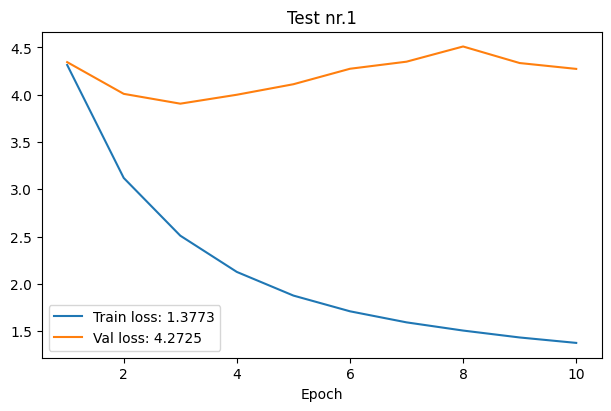

In [79]:
trainer.fit(model, train_data, val_data)

### 6. Prediction

In [116]:
def sentence_to_tokens(sentence, vocab, max_len=34):
    sentence_split = tokenize_eng(sentence)
    if len(sentence_split) > max_len:
        return "Sentence exceeded 34 tokens"
    print([x if x in vocab else '<unk>'  for x in sentence_split])
    sentence_ids = tokens_to_id(sentence_split, vocab)
    return torch.tensor(sentence_ids).reshape(1, -1), torch.tensor([len(sentence_ids)])
    

In [301]:
test_src, test_val_len = sentence_to_tokens("Hello world.", eng_vocab)
test_src, test_val_len

['my', 'dad', 'is', 'a', 'real', 'estate', 'agent', '.', '<eos>']


(tensor([[  22,  940,   11,    8,  690, 3092, 4536,    3,    2]]), tensor([9]))

In [ ]:
def snt_to_tokens(snt_eng, vocab_eng, device='cuda', max_len=34):
    snt_split = tokenize_eng(snt_eng)[:max_len]
    snt_ids = tokens_to_id(snt_split, vocab_eng)
    return torch.tensor(snt_ids).reshape(1, -1).to(device), torch.tensor([len(snt_ids)]).to(device)


def tokens_to_snt(pred_ids, vcb_pol_rev):
    snt_pred = list(map(torch.Tensor.item, pred_ids))
    return [vcb_pol_rev[x] for x in snt_pred]

def predict_step(snt_eng, vcb_eng, vcb_pol, vcb_pol_rev, model, device='cuda', max_len=34):
    
    src_eng, src_len = snt_to_tokens(snt_eng, vcb_eng, device, max_len)
    bos_id, eos_id = vcb_pol['<bos>'], vcb_pol['eos']
    
    with torch.no_grad():
        model.eval()
        X_enc = model.encoder(src_eng, src_len)
        dec_state = model.decoder.init_state(X_enc, src_len)
        pred_ids = [torch.tensor(bos_id).reshape(1, -1).to(device)]

        for _ in range(max_len):
            Y_dec, dec_state = model.decoder(pred_ids[-1], dec_state)
            pred_ids.append(Y_dec.argmax(2))
            if pred_ids[-1].item() == eos_id:
                break
    return tokens_to_snt(pred_ids, vcb_pol_rev)
    

In [ ]:
predict_step("Hello world!", eng_vocab, pol_vocab, pol_vocab_rev, model)

In [302]:
with torch.no_grad():
    model.eval()
    test_src, test_val_len = test_src.to('cuda'), test_val_len.to('cuda')
    X_enc_test = encoder(test_src, test_val_len)
    dec_state = decoder.init_state(X_enc_test, test_val_len)
    X_dec_test = torch.tensor([pol_vocab['<bos>']]).reshape(1, -1).to('cuda')
    eos_id = pol_vocab['<eos>']
    predicted = [X_dec_test]
    for _ in range(34):
        Y_dec_test, dec_state = decoder(predicted[-1], dec_state)
        Y_predicted = Y_dec_test.argmax(2)
        predicted.append(Y_predicted)
        if Y_predicted.item() == eos_id:
            break

In [303]:
pred_sent = [ten.item() for ten in predicted]
print([id_to_tok(x, pol_vocab) for x in pred_sent])

['<bos>', 'mój', 'tata', 'jest', 'agentem', 'nieruchomości', '.', '<eos>']


In [119]:
test_src.shape, test_src, '', test_val_len.shape, test_val_len

(torch.Size([1, 6]),
 tensor([[ 30,  11,  33, 230,  10,   2]]),
 '',
 torch.Size([1]),
 tensor([6]))

In [212]:
def id_to_tok(tok_id, vocab):
    return [k for k, v in vocab.items() if v == tok_id][0] #odwroc dictionary aby bylo szybciej i ladniej

In [ ]:
def predict_step(eng_src, eng_val_len, model):
    